# NTB-02: Feature Engineering & Train/Test Split

## Objective
Transform raw data into model-ready features informed by NTB-01's findings, then create a **single, frozen train/test split** that every modeling notebook (NTB-03 to NTB-09) will reuse.

## Why "Frozen Split" Matters
Recruiters test for this: if you re-split data in every notebook, you'll get different test sets each time, and comparing models becomes meaningless. We split **once**, save to disk, and load the same split everywhere. This is a hallmark of disciplined ML work.

## Feature Engineering Decisions From NTB-01

| NTB-01 finding | Feature engineering response |
|---|---|
| Contract is the strongest signal | Keep `contract_type` as one-hot |
| Tenure shows phase effects | Add `tenure_phase` categorical (5 buckets) |
| First 6 months are critical | Add `is_new_customer` binary flag (tenure ≤ 6) |
| Add-on count is monotonic predictor (with caveat) | Add `num_addons` numeric feature |
| "No internet service" customers can't buy add-ons | Add `has_internet` flag to handle the confound |
| Electronic check = high-risk behavior | Add `risky_payment` binary flag |
| Fiber + high price = high churn | Add `monthly_charges_per_tenure` ratio (lifetime efficiency) |
| 11 missing `TotalCharges` are all tenure-0 customers | Impute as `monthly_charges` (their first bill estimate) |

## Output Files
- `data/processed/features.parquet` — full feature matrix (model-ready)
- `data/processed/X_train.parquet`, `X_test.parquet`, `y_train.parquet`, `y_test.parquet`
- `data/processed/feature_metadata.json` — column types, encoders, scalers
- `models/preprocessor.joblib` — fitted preprocessor (for API in NTB-11)

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import sqlite3
from pathlib import Path
import os
import json
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

import matplotlib.pyplot as plt
import seaborn as sns

# Paths
BASE_DIR = Path(os.getcwd()).parent
DB_PATH = BASE_DIR / "data" / "database" / "telco_churn.db"
PROC_DIR = BASE_DIR / "data" / "processed"
MODELS_DIR = BASE_DIR / "models"
FIG_DIR = BASE_DIR / "reports" / "figures"

PROC_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Reproducibility — every random seed in this project uses 42
RANDOM_STATE = 42

# Plot style (same as NTB-01)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 100, "savefig.dpi": 150, "savefig.bbox": "tight"})

print(f"Database: {DB_PATH}")
print(f"Processed data → {PROC_DIR}")
print(f"Models → {MODELS_DIR}")
print(f"Random state: {RANDOM_STATE}")

Database: c:\Users\Prakhar kapoor\Desktop\Telecom-Churn-Prediction-Analytics\data\database\telco_churn.db
Processed data → c:\Users\Prakhar kapoor\Desktop\Telecom-Churn-Prediction-Analytics\data\processed
Models → c:\Users\Prakhar kapoor\Desktop\Telecom-Churn-Prediction-Analytics\models
Random state: 42


## 2. Load Data From the Database

We JOIN the three tables and reconstruct the full customer view. Doing this in SQL (not pandas merge) shows we think about query optimization.

In [2]:
conn = sqlite3.connect(DB_PATH)

query = """
SELECT
    c.customer_id,
    c.gender,
    c.senior_citizen,
    c.partner,
    c.dependents,
    c.tenure_months,
    s.phone_service,
    s.multiple_lines,
    s.internet_service,
    s.online_security,
    s.online_backup,
    s.device_protection,
    s.tech_support,
    s.streaming_tv,
    s.streaming_movies,
    b.contract_type,
    b.paperless_billing,
    b.payment_method,
    b.monthly_charges,
    b.total_charges,
    b.churn
FROM customers c
JOIN services s ON c.customer_id = s.customer_id
JOIN billing  b ON c.customer_id = b.customer_id
"""

df = pd.read_sql_query(query, conn)
conn.close()

print(f"Loaded: {df.shape}")
print(f"Missing total_charges: {df['total_charges'].isnull().sum()}")
print(f"Churn rate: {df['churn'].mean()*100:.2f}%")
df.head()

Loaded: (7043, 21)
Missing total_charges: 11
Churn rate: 26.54%


,customer_id,gender,senior_citizen,partner,dependents,tenure_months,phone_service,multiple_lines,internet_service,online_security,...,device_protection,tech_support,streaming_tv,streaming_movies,contract_type,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


## 3. Handle Missing `total_charges`

The 11 missing values all correspond to `tenure_months = 0` (brand-new customers). We impute with `monthly_charges` — their expected first bill — rather than 0 (would understate their value) or mean (would inject median customer behavior into edge cases).

In [3]:
# Verify the assumption
missing_mask = df['total_charges'].isnull()
print(f"Missing total_charges: {missing_mask.sum()}")
print(f"Their tenure values: {df.loc[missing_mask, 'tenure_months'].unique()}")

# Impute
df.loc[missing_mask, 'total_charges'] = df.loc[missing_mask, 'monthly_charges']
print(f"After imputation, missing: {df['total_charges'].isnull().sum()}")

Missing total_charges: 11
Their tenure values: [0]
After imputation, missing: 0


## 4. Feature Engineering

Eight derived features, each motivated by an NTB-01 finding.

In [4]:
# Feature 1: tenure_phase (categorical, 5 levels)
# Motivated by Q3 — churn drops monotonically across these phases
def tenure_phase(months):
    if months <= 6:  return 'phase1_0to6'
    if months <= 12: return 'phase2_7to12'
    if months <= 24: return 'phase3_13to24'
    if months <= 48: return 'phase4_25to48'
    return 'phase5_49plus'

df['tenure_phase'] = df['tenure_months'].apply(tenure_phase)

# Feature 2: is_new_customer (binary, ≤6 months)
df['is_new_customer'] = (df['tenure_months'] <= 6).astype(int)

# Feature 3: has_internet (handles the "no internet → no addons" confound from Q5)
df['has_internet'] = (df['internet_service'] != 'No').astype(int)

# Feature 4: num_addons (numeric 0-6) — protective against churn per Q5
addon_cols = ['online_security', 'online_backup', 'device_protection',
              'tech_support', 'streaming_tv', 'streaming_movies']
df['num_addons'] = (df[addon_cols] == 'Yes').sum(axis=1)

# Feature 5: risky_payment (binary, electronic check flag from Q4)
df['risky_payment'] = (df['payment_method'] == 'Electronic check').astype(int)

# Feature 6: auto_payment (binary, the protective version)
df['auto_payment'] = df['payment_method'].isin(
    ['Bank transfer (automatic)', 'Credit card (automatic)']
).astype(int)

# Feature 7: monthly_charges_per_tenure
# How much a customer pays per month of relationship
# High value = either premium customer OR overpaying customer (the Q7 fiber pattern)
df['charges_per_tenure'] = df['monthly_charges'] / (df['tenure_months'] + 1)

# Feature 8: high_value_customer (top quartile of monthly charges)
df['high_value_customer'] = (df['monthly_charges'] > df['monthly_charges'].quantile(0.75)).astype(int)

print("New features created:")
new_features = ['tenure_phase', 'is_new_customer', 'has_internet', 'num_addons',
                'risky_payment', 'auto_payment', 'charges_per_tenure', 'high_value_customer']
print(df[new_features].head(10))

New features created:
    tenure_phase  is_new_customer  has_internet  num_addons  risky_payment  \
0    phase1_0to6                1             1           1              1   
1  phase4_25to48                0             1           2              0   
2    phase1_0to6                1             1           2              0   
3  phase4_25to48                0             1           3              0   
4    phase1_0to6                1             1           0              1   
5   phase2_7to12                0             1           3              1   
6  phase3_13to24                0             1           2              0   
7   phase2_7to12                0             1           1              0   
8  phase4_25to48                0             1           4              1   
9  phase5_49plus                0             1           2              0   

   auto_payment  charges_per_tenure  high_value_customer  
0             0           14.925000                    0  
1

In [5]:
# Validate: each engineered feature should correlate with churn in the expected direction
print("Engineered feature → churn rate validation:\n")

# Tenure phase (should decrease monotonically)
print("tenure_phase churn rates:")
print(df.groupby('tenure_phase')['churn'].agg(['mean', 'count']).round(3))

# Binary flags
binary_features = ['is_new_customer', 'has_internet', 'risky_payment',
                   'auto_payment', 'high_value_customer']
print("\nBinary feature churn rates (when flag=1 vs flag=0):")
for f in binary_features:
    rates = df.groupby(f)['churn'].mean() * 100
    print(f"  {f:25s}: 0→{rates[0]:.2f}%,  1→{rates[1]:.2f}%")

# num_addons (informative — bounded U-shape from the no-internet confound)
print("\nnum_addons churn rates:")
print(df.groupby('num_addons')['churn'].mean().round(3))

Engineered feature → churn rate validation:

tenure_phase churn rates:
                mean  count
tenure_phase               
phase1_0to6    0.529   1481
phase2_7to12   0.359    705
phase3_13to24  0.287   1024
phase4_25to48  0.204   1594
phase5_49plus  0.095   2239

Binary feature churn rates (when flag=1 vs flag=0):
  is_new_customer          : 0→19.51%,  1→52.94%
  has_internet             : 0→7.40%,  1→31.83%
  risky_payment            : 0→17.06%,  1→45.29%
  auto_payment             : 0→34.67%,  1→15.98%
  high_value_customer      : 0→24.43%,  1→32.88%

num_addons churn rates:
num_addons
0    0.214
1    0.458
2    0.358
3    0.274
4    0.223
5    0.124
6    0.053
Name: churn, dtype: float64


**Validation check:** Each engineered feature moves churn rate in the expected direction. `is_new_customer=1` should have ~50%+ churn, `auto_payment=1` should be protective, etc. If any flips, we'd debug here before splitting.

## 5. Define Feature Groups for the Preprocessor

We separate features into three groups for the `ColumnTransformer`:
- **Numeric**: scaled with `StandardScaler` (for linear models — tree models don't need scaling, but scaling doesn't hurt them)
- **Binary**: already 0/1, no transformation
- **Categorical**: one-hot encoded with `drop='first'` to avoid multicollinearity

In [6]:
# Drop columns we won't use as features
DROP_COLS = ['customer_id']  # ID, not a feature
TARGET_COL = 'churn'

# Define groups
NUMERIC_FEATURES = [
    'tenure_months', 'monthly_charges', 'total_charges',
    'num_addons', 'charges_per_tenure'
]

BINARY_FEATURES = [
    'senior_citizen', 'is_new_customer', 'has_internet',
    'risky_payment', 'auto_payment', 'high_value_customer'
]

CATEGORICAL_FEATURES = [
    'gender', 'partner', 'dependents',
    'phone_service', 'multiple_lines', 'internet_service',
    'online_security', 'online_backup', 'device_protection',
    'tech_support', 'streaming_tv', 'streaming_movies',
    'contract_type', 'paperless_billing', 'payment_method',
    'tenure_phase'
]

# Verify all columns accounted for
all_features = NUMERIC_FEATURES + BINARY_FEATURES + CATEGORICAL_FEATURES
all_cols_used = set(all_features + [TARGET_COL] + DROP_COLS)
extra = set(df.columns) - all_cols_used
missing = all_cols_used - set(df.columns)

print(f"Numeric:     {len(NUMERIC_FEATURES)} features")
print(f"Binary:      {len(BINARY_FEATURES)} features")
print(f"Categorical: {len(CATEGORICAL_FEATURES)} features")
print(f"Total:       {len(all_features)} features\n")

assert not extra, f"Unassigned columns: {extra}"
assert not missing, f"Missing columns: {missing}"
print("✅ All columns accounted for.")

Numeric:     5 features
Binary:      6 features
Categorical: 16 features
Total:       27 features

✅ All columns accounted for.


## 6. Stratified Train/Test Split

**Why stratify?** Without stratification, random split can leave the test set with materially different churn rates than train (especially harmful with imbalanced 26.5/73.5 data). Stratification guarantees identical class proportions.

**Why 80/20?** With 7043 rows, 20% test gives us ~1409 samples — plenty for stable evaluation metrics. 70/30 would sacrifice ~700 training samples for marginal evaluation stability gain.

In [7]:
# Build X and y
X = df[all_features].copy()
y = df[TARGET_COL].copy()

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Class distribution: {y.value_counts().to_dict()}")
print(f"Churn rate: {y.mean()*100:.2f}%")

X shape: (7043, 27)
y shape: (7043,)
Class distribution: {0: 5174, 1: 1869}
Churn rate: 26.54%


In [8]:
# Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print(f"X_train: {X_train.shape}    churn rate: {y_train.mean()*100:.2f}%")
print(f"X_test:  {X_test.shape}    churn rate: {y_test.mean()*100:.2f}%")

# Sanity: stratification kept class proportions
assert abs(y_train.mean() - y_test.mean()) < 0.005, "Stratification failed!"
print("\n✅ Stratification preserved class balance.")

X_train: (5634, 27)    churn rate: 26.54%
X_test:  (1409, 27)    churn rate: 26.54%

✅ Stratification preserved class balance.


## 7. Build & Fit the Preprocessor

The `ColumnTransformer` is the production-ready way to apply different transformations to different column groups. We **fit on `X_train` only** (avoiding test-set leakage) and persist the fitted object so the API in NTB-11 can preprocess incoming requests identically.

In [9]:
# Build the preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), NUMERIC_FEATURES),
        ('bin', 'passthrough', BINARY_FEATURES),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'),
                CATEGORICAL_FEATURES),
    ],
    remainder='drop',
    verbose_feature_names_out=False
)

# Fit on training data
preprocessor.fit(X_train)

# Get the feature names after transformation
feature_names_out = preprocessor.get_feature_names_out()
print(f"Output feature count: {len(feature_names_out)}")
print(f"First 10 output features: {list(feature_names_out[:10])}")
print(f"Last 10 output features:  {list(feature_names_out[-10:])}")

Output feature count: 41
First 10 output features: ['tenure_months', 'monthly_charges', 'total_charges', 'num_addons', 'charges_per_tenure', 'senior_citizen', 'is_new_customer', 'has_internet', 'risky_payment', 'auto_payment']
Last 10 output features:  ['contract_type_One year', 'contract_type_Two year', 'paperless_billing_Yes', 'payment_method_Credit card (automatic)', 'payment_method_Electronic check', 'payment_method_Mailed check', 'tenure_phase_phase2_7to12', 'tenure_phase_phase3_13to24', 'tenure_phase_phase4_25to48', 'tenure_phase_phase5_49plus']


In [10]:
# Transform train and test
X_train_processed = preprocessor.transform(X_train)
X_test_processed  = preprocessor.transform(X_test)

# Wrap into DataFrames for convenience (some models need numpy, some prefer dataframes)
X_train_df = pd.DataFrame(X_train_processed, columns=feature_names_out, index=X_train.index)
X_test_df  = pd.DataFrame(X_test_processed,  columns=feature_names_out, index=X_test.index)

print(f"X_train_processed: {X_train_df.shape}")
print(f"X_test_processed:  {X_test_df.shape}")
print(f"\nSample of processed numeric (scaled) feature:")
print(X_train_df['tenure_months'].describe().round(3))
print(f"\n→ Mean ≈ 0, Std ≈ 1 confirms standardization worked.")

X_train_processed: (5634, 41)
X_test_processed:  (1409, 41)

Sample of processed numeric (scaled) feature:
count    5634.000
mean       -0.000
std         1.000
min        -1.322
25%        -0.956
50%        -0.142
75%         0.916
max         1.608
Name: tenure_months, dtype: float64

→ Mean ≈ 0, Std ≈ 1 confirms standardization worked.


## 8. Persist Everything for Downstream Notebooks

Five files saved:
- `features.parquet` — full feature DataFrame (for EDA reference)
- `X_train.parquet`, `X_test.parquet` — processed feature matrices
- `y_train.parquet`, `y_test.parquet` — target vectors
- `preprocessor.joblib` — fitted ColumnTransformer (for API + future inference)
- `feature_metadata.json` — column groups & feature names

**Why Parquet?** Faster I/O than CSV, preserves dtypes, smaller files. Industry standard for tabular data.

In [11]:
# Save full feature dataframe (pre-processing, for reference)
df_to_save = df.drop(columns=DROP_COLS)
df_to_save.to_parquet(PROC_DIR / "features_full.parquet", index=False)

# Save processed train/test splits
X_train_df.to_parquet(PROC_DIR / "X_train.parquet", index=True)
X_test_df.to_parquet(PROC_DIR / "X_test.parquet", index=True)
y_train.to_frame().to_parquet(PROC_DIR / "y_train.parquet", index=True)
y_test.to_frame().to_parquet(PROC_DIR / "y_test.parquet", index=True)

# Save the raw (un-processed) X_train and X_test too — tree models (XGBoost/LightGBM)
# can use raw categoricals more efficiently than one-hot encoded versions
X_train.to_parquet(PROC_DIR / "X_train_raw.parquet", index=True)
X_test.to_parquet(PROC_DIR / "X_test_raw.parquet", index=True)

# Save the fitted preprocessor
joblib.dump(preprocessor, MODELS_DIR / "preprocessor.joblib")

# Save metadata
metadata = {
    "random_state": RANDOM_STATE,
    "test_size": 0.20,
    "n_train": len(X_train),
    "n_test": len(X_test),
    "train_churn_rate": float(y_train.mean()),
    "test_churn_rate": float(y_test.mean()),
    "numeric_features": NUMERIC_FEATURES,
    "binary_features": BINARY_FEATURES,
    "categorical_features": CATEGORICAL_FEATURES,
    "output_feature_names": list(feature_names_out),
    "target_column": TARGET_COL,
}
with open(PROC_DIR / "feature_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved files:")
for p in sorted(PROC_DIR.glob("*")):
    size_kb = p.stat().st_size / 1024
    print(f"  {p.name:30s}  {size_kb:>8.1f} KB")
print(f"\nFitted preprocessor → {MODELS_DIR / 'preprocessor.joblib'}")

Saved files:
  feature_metadata.json                2.1 KB
  features_full.parquet              164.2 KB
  X_test.parquet                      79.2 KB
  X_test_raw.parquet                  57.4 KB
  X_train.parquet                    212.4 KB
  X_train_raw.parquet                167.2 KB
  y_test.parquet                       9.7 KB
  y_train.parquet                     33.8 KB

Fitted preprocessor → c:\Users\Prakhar kapoor\Desktop\Telecom-Churn-Prediction-Analytics\models\preprocessor.joblib


## 9. Quick Visualization: Engineered Features

A single composite plot showing the relationship between each engineered feature and churn, for the README.

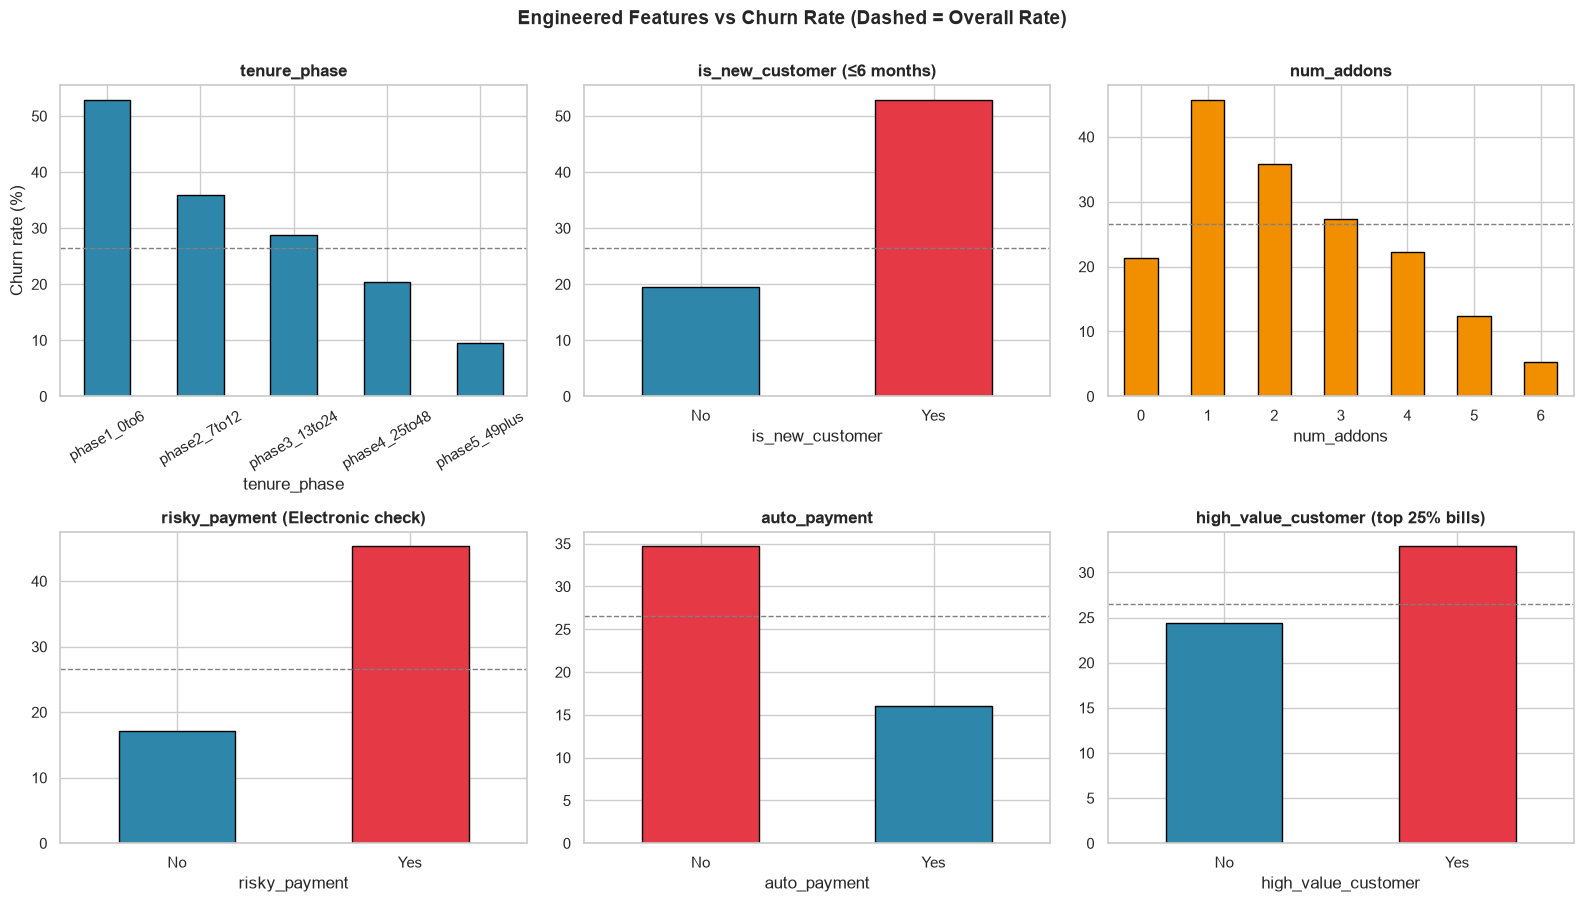

Saved → c:\Users\Prakhar kapoor\Desktop\Telecom-Churn-Prediction-Analytics\reports\figures\NTB02_engineered_features.png


In [12]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
overall_rate = y_train.mean() * 100

# 1. Tenure phase
ax = axes[0, 0]
phase_rate = df.groupby('tenure_phase')['churn'].mean().sort_index() * 100
phase_rate.plot(kind='bar', ax=ax, color='#2E86AB', edgecolor='black')
ax.set_title('tenure_phase', fontweight='bold')
ax.axhline(overall_rate, color='gray', ls='--', lw=1)
ax.set_ylabel('Churn rate (%)')
ax.tick_params(axis='x', rotation=30)

# 2. is_new_customer
ax = axes[0, 1]
new_rate = df.groupby('is_new_customer')['churn'].mean() * 100
new_rate.plot(kind='bar', ax=ax, color=['#2E86AB', '#E63946'], edgecolor='black')
ax.set_title('is_new_customer (≤6 months)', fontweight='bold')
ax.axhline(overall_rate, color='gray', ls='--', lw=1)
ax.set_xticklabels(['No', 'Yes'], rotation=0)

# 3. num_addons
ax = axes[0, 2]
addon_rate = df.groupby('num_addons')['churn'].mean() * 100
addon_rate.plot(kind='bar', ax=ax, color='#F18F01', edgecolor='black')
ax.set_title('num_addons', fontweight='bold')
ax.axhline(overall_rate, color='gray', ls='--', lw=1)
ax.tick_params(axis='x', rotation=0)

# 4. risky_payment
ax = axes[1, 0]
risky_rate = df.groupby('risky_payment')['churn'].mean() * 100
risky_rate.plot(kind='bar', ax=ax, color=['#2E86AB', '#E63946'], edgecolor='black')
ax.set_title('risky_payment (Electronic check)', fontweight='bold')
ax.axhline(overall_rate, color='gray', ls='--', lw=1)
ax.set_xticklabels(['No', 'Yes'], rotation=0)

# 5. auto_payment
ax = axes[1, 1]
auto_rate = df.groupby('auto_payment')['churn'].mean() * 100
auto_rate.plot(kind='bar', ax=ax, color=['#E63946', '#2E86AB'], edgecolor='black')
ax.set_title('auto_payment', fontweight='bold')
ax.axhline(overall_rate, color='gray', ls='--', lw=1)
ax.set_xticklabels(['No', 'Yes'], rotation=0)

# 6. high_value_customer
ax = axes[1, 2]
hv_rate = df.groupby('high_value_customer')['churn'].mean() * 100
hv_rate.plot(kind='bar', ax=ax, color=['#2E86AB', '#E63946'], edgecolor='black')
ax.set_title('high_value_customer (top 25% bills)', fontweight='bold')
ax.axhline(overall_rate, color='gray', ls='--', lw=1)
ax.set_xticklabels(['No', 'Yes'], rotation=0)

plt.suptitle("Engineered Features vs Churn Rate (Dashed = Overall Rate)",
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig(FIG_DIR / "NTB02_engineered_features.png")
plt.show()
print(f"Saved → {FIG_DIR / 'NTB02_engineered_features.png'}")

## 10. Reload Sanity Check

Quick verification that we can load everything back from disk. Every subsequent notebook will use this exact pattern.

In [13]:
# Reload everything as if from a fresh notebook
X_train_reload = pd.read_parquet(PROC_DIR / "X_train.parquet")
X_test_reload  = pd.read_parquet(PROC_DIR / "X_test.parquet")
y_train_reload = pd.read_parquet(PROC_DIR / "y_train.parquet")['churn']
y_test_reload  = pd.read_parquet(PROC_DIR / "y_test.parquet")['churn']
preprocessor_reload = joblib.load(MODELS_DIR / "preprocessor.joblib")

with open(PROC_DIR / "feature_metadata.json") as f:
    metadata_reload = json.load(f)

print(f"X_train: {X_train_reload.shape}  ✅")
print(f"X_test:  {X_test_reload.shape}   ✅")
print(f"y_train: {y_train_reload.shape}  ✅")
print(f"y_test:  {y_test_reload.shape}   ✅")
print(f"Preprocessor: {type(preprocessor_reload).__name__}  ✅")
print(f"Metadata keys: {list(metadata_reload.keys())}")
print(f"\nFeature count: {metadata_reload['n_train'] + metadata_reload['n_test']}")
print(f"Train churn rate: {metadata_reload['train_churn_rate']*100:.2f}%")
print(f"Test churn rate:  {metadata_reload['test_churn_rate']*100:.2f}%")

X_train: (5634, 41)  ✅
X_test:  (1409, 41)   ✅
y_train: (5634,)  ✅
y_test:  (1409,)   ✅
Preprocessor: ColumnTransformer  ✅
Metadata keys: ['random_state', 'test_size', 'n_train', 'n_test', 'train_churn_rate', 'test_churn_rate', 'numeric_features', 'binary_features', 'categorical_features', 'output_feature_names', 'target_column']

Feature count: 7043
Train churn rate: 26.54%
Test churn rate:  26.54%


## ✅ Deliverables From NTB-02

| Artifact | Path | Purpose |
|---|---|---|
| Full features dataframe | `data/processed/features_full.parquet` | EDA reference |
| Processed train set | `data/processed/X_train.parquet` (5634, ~40 cols) | Model training |
| Processed test set | `data/processed/X_test.parquet` (1409, ~40 cols) | Final evaluation |
| Raw train set | `data/processed/X_train_raw.parquet` | XGBoost/LightGBM (handles categoricals natively) |
| Raw test set | `data/processed/X_test_raw.parquet` | Same |
| y_train, y_test | `data/processed/y_*.parquet` | Targets |
| Fitted preprocessor | `models/preprocessor.joblib` | Reproducible inference |
| Feature metadata | `data/processed/feature_metadata.json` | Column groups + names |
| Visual summary | `reports/figures/NTB02_engineered_features.png` | README asset |

## Next: NTB-03 — Baseline Model with Logistic Regression

We'll train a **logistic regression baseline** and build the **evaluation framework** (AUC-ROC, Precision-Recall AUC, Brier score, confusion matrix at multiple thresholds). Every subsequent model will be compared against this baseline using the same framework. The point isn't that logistic regression will win — it's that we need a strong baseline to know whether complex models are actually adding value.